<a href="https://colab.research.google.com/github/astrophillie/telco-churn-ml-comparison/blob/main/project01_ML_training_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction

## 1. Project objective

Scopul proiectului este sa estimez daca un client va renunta la serviciile companiei de telecomunicatii, folosind informatii despre contract, vechime, servicii si costuri.

Voi compara un model simplu si usor de interpretat, **Logistic Regression**, cu un model capabil sa surprinda relatii mai complexe, **Random Forest**. Performanta lor va fi raportata si la un `DummyClassifier`, care reprezinta nivelul obtinut de un model fara capacitate reala de invatare.

In acest context, o predictie fals negativa este deosebit de importanta: clientul urmeaza sa plece, dar modelul il clasifica drept client care ramane. Compania pierde astfel ocazia de a interveni printr-o oferta sau o actiune de retentie. Din acest motiv, voi urmari cu atentie **recall-ul clasei Churn**, impreuna cu F1-score, precision si ROC-AUC.

## 2. Dataset loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

dataset_url = (
    "https://raw.githubusercontent.com/"
    "IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)
telco_df = pd.read_csv(dataset_url)
display(telco_df.head())
print("shape:", telco_df.shape)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


shape: (7043, 21)


Am afisat primele 5 randuri pentru a verifica daca setul de date a fost incarcat corect si daca valorile sunt organizate in coloanele asteptate.

Setul de date obtinut contine **7.043 de randuri si 21 de coloane**. Fiecare rand reprezinta un client, iar fiecare coloana descrie o caracteristica a acestuia.

## 3. Data exploration

### 3.1 Dataset structure


In [3]:

print("number of rows:", telco_df.shape[0])
print("number of columns:", telco_df.shape[1])
print("\ncolumn names:")
print(telco_df.columns.tolist())
print("\ndata types:")
print(telco_df.dtypes)
print("\ndataset information:")
telco_df.info()

number of rows: 7043
number of columns: 21

column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

da

In urma inspectarii datelor, am concluzionat urmatoarele:

- `tenure` si `MonthlyCharges` sunt variabile numerice.
- `SeniorCitizen` este stocata numeric, desi reprezinta o categorie cu doua valori.
- `TotalCharges` apare ca `object`, desi reprezinta o suma, ceea ce inseamna ca va trebui transformata intr-o variabila numerica.
- `customerID` are o valoare diferita pentru fiecare client. Este doar un identificator si nu ofera un tipar general pe care modelul il poate invata. Prin urmare, va fi eliminat inainte de antrenare.
- `Churn` este variabila tinta si va trebui transformata din valorile `Yes` si `No` in format numeric.

### 3.2 Missing values and duplicates

In [4]:
print("missing values:")
print(telco_df.isna().sum())

print("\nblank values in text columns:")
blank_values = telco_df.select_dtypes(include="object").apply(
    lambda column: column.str.strip().eq("").sum()
)
print(blank_values[blank_values > 0])

print("\nduplicate rows:", telco_df.duplicated().sum())

blank_total_charges = blank_values["TotalCharges"]
blank_percentage = blank_total_charges / telco_df.shape[0] * 100

print("\nblank TotalCharges values:", blank_total_charges)
print(f"percentage of dataset: {blank_percentage:.2f}%")

missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

blank values in text columns:
TotalCharges    11
dtype: int64

duplicate rows: 0

blank TotalCharges values: 11
percentage of dataset: 0.16%


Nu am identificat valori `NaN` sau randuri duplicate. Totusi, in coloana `TotalCharges` am identificat **11 valori goale**, care nu au fost recunoscute automat drept valori lipsa deoarece coloana este stocata ca text.

Pentru calcularea procentului am folosit formula:

**procent valori goale = numar valori goale / numar total de randuri × 100**

In cazul acestui set de date:

**11 / 7.043 × 100 = 0,16%**

Aceste valori goale trebuie tratate pentru a putea transforma corect coloana `TotalCharges` in format numeric.


### 3.3 Target distribution

In [5]:
churn_counts = telco_df["Churn"].value_counts()
churn_percentages = telco_df["Churn"].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "number_of_customers": churn_counts,
    "percentage": churn_percentages.round(2)
})

display(target_distribution)

,number_of_customers,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


Din totalul de **7.043 de clienti**, **5.174 (73,46%)** au ramas in companie, iar **1.869 (26,54%)** au renuntat la servicii.

Cele doua clase nu sunt echilibrate, deoarece numarul clientilor care au ramas este mult mai mare decat numarul celor care au plecat.

Din acest motiv, nu voi evalua modelele doar pe baza accuracy-ului. Voi urmari **recall-ul pentru `Churn = Yes`**, pentru a vedea cati dintre clientii care au plecat au fost identificati corect de model.

### 3.4 Data visualisation


In [6]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FAFAFA"
})

stay_color = "#6C5CE7"
churn_color = "#FF7675"
accent_color = "#00B894"

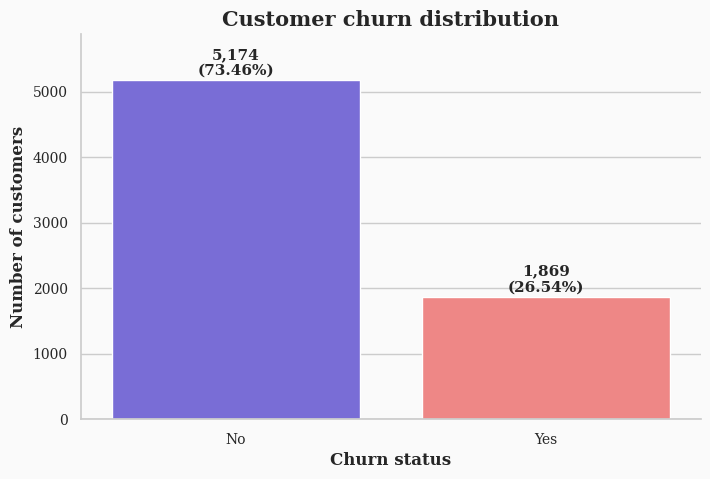

In [7]:
churn_counts = telco_df["Churn"].value_counts().reindex(["No", "Yes"])
churn_percentages = churn_counts / churn_counts.sum() * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    hue=churn_counts.index,
    palette={"No": stay_color, "Yes": churn_color},
    legend=False
)

for index, (count, percentage) in enumerate(
    zip(churn_counts, churn_percentages)
):
    ax.text(
        index,
        count + 80,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        fontweight="bold"
    )

plt.title(
    "Customer churn distribution",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Churn status")
plt.ylabel("Number of customers")
plt.ylim(0, churn_counts.max() + 700)
sns.despine()
plt.show()

Prin acest grafic putem confirma dezechilibrul observat anterior: clientii care au ramas sunt mult mai numerosi decat cei care au plecat.

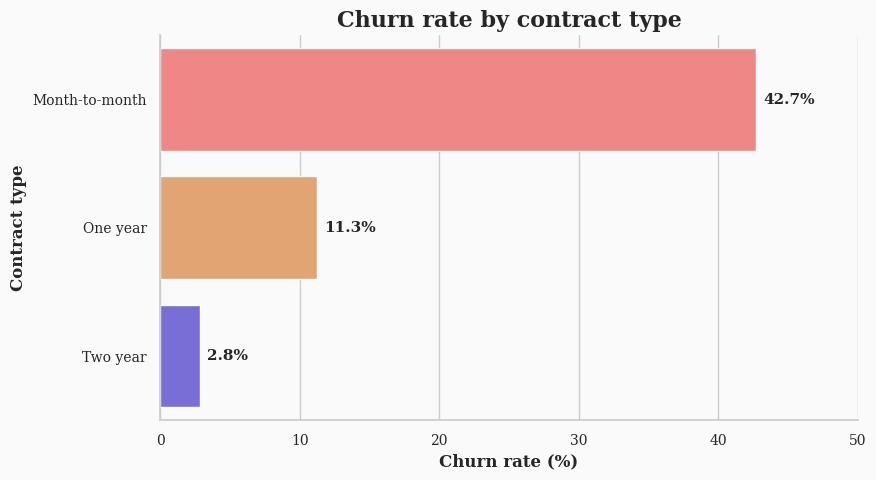

In [8]:
contract_order = [
    "Month-to-month",
    "One year",
    "Two year"
]

contract_churn_rate = (
    telco_df.groupby("Contract", observed=False)["Churn"]
    .apply(lambda values: values.eq("Yes").mean() * 100)
    .reindex(contract_order)
    .reset_index(name="churn_rate")
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=contract_churn_rate,
    y="Contract",
    x="churn_rate",
    hue="Contract",
    palette=[churn_color, "#F4A261", stay_color],
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontweight="bold"
    )

plt.title("Churn rate by contract type")
plt.xlabel("Churn rate (%)")
plt.ylabel("Contract type")
plt.xlim(0, 50)
sns.despine()
plt.show()

Clientii cu abonament lunar au cea mai mare rata de plecare. In schimb, clientii cu contracte pe un an sau doi ani par sa ramana mai des in companie. In concluzie, tipul contractului ar putea fi o caracteristica importanta pentru predictie.

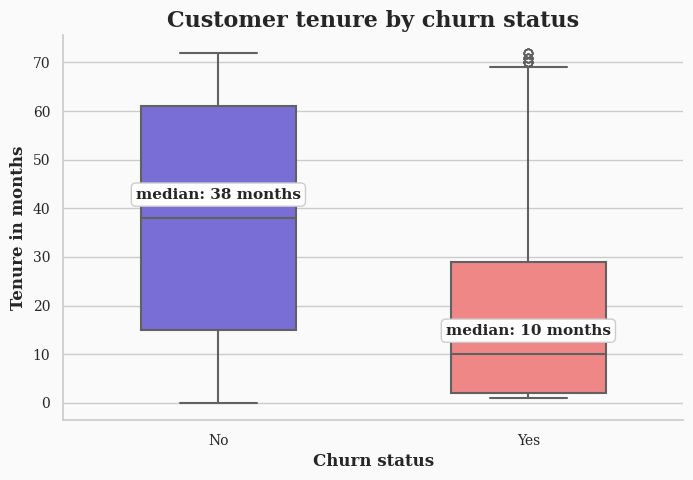

In [9]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=telco_df,
    x="Churn",
    y="tenure",
    hue="Churn",
    palette={"No": stay_color, "Yes": churn_color},
    legend=False,
    width=0.5,
    linewidth=1.5
)

tenure_medians = (
    telco_df.groupby("Churn")["tenure"]
    .median()
    .reindex(["No", "Yes"])
)

for index, median in enumerate(tenure_medians):
    ax.text(
        index,
        median + 4,
        f"median: {median:.0f} months",
        ha="center",
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "#CCCCCC",
            "boxstyle": "round,pad=0.3"
        }
    )

plt.title("Customer tenure by churn status")
plt.xlabel("Churn status")
plt.ylabel("Tenure in months")
sns.despine()
plt.show()

Clientii care au renuntat la servicii au o vechime mai mica. Acest rezultat sugereaza ca riscul de plecare este mai ridicat in primele luni ale relatiei cu compania.

## 4. Data preparation

### 4.1 Data cleaning

In [10]:
telco_clean_df = telco_df.copy()

initial_rows = telco_clean_df.shape[0]

telco_clean_df["TotalCharges"] = pd.to_numeric(
    telco_clean_df["TotalCharges"],
    errors="coerce"
)

telco_clean_df = (
    telco_clean_df
    .dropna(subset=["TotalCharges"])
    .reset_index(drop=True)
)

removed_rows = initial_rows - telco_clean_df.shape[0]

print("TotalCharges data type:", telco_clean_df["TotalCharges"].dtype)
print("removed rows:", removed_rows)
print("remaining rows:", telco_clean_df.shape[0])
print(
    "remaining missing TotalCharges values:",
    telco_clean_df["TotalCharges"].isna().sum()
)

TotalCharges data type: float64
removed rows: 11
remaining rows: 7032
remaining missing TotalCharges values: 0


Am transformat coloana `TotalCharges` din text in numere, iar cele **11 randuri** care aveau valori goale au fost eliminate, rezultand astfel **7.032 de clienti**.

### 4.2 Feature engineering

In [11]:
telco_clean_df["tenure_group"] = pd.cut(
    telco_clean_df["tenure"],
    bins=[0, 12, 48, 72],
    labels=["new customer", "established customer", "loyal customer"],
    include_lowest=True
)

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

telco_clean_df["number_of_services"] = (
    telco_clean_df[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

display(
    telco_clean_df[
        ["tenure", "tenure_group", "number_of_services"]
    ].head()
)

,tenure,tenure_group,number_of_services
0,1,new customer,1
1,34,established customer,3
2,2,new customer,3
3,45,established customer,3
4,2,new customer,1


Am creat doua caracteristici noi pe baza informatiilor existente:

`tenure_group` imparte clientii in trei categorii: clienti noi, clienti cu vechime medie si clienti loiali. Astfel, modelul poate observa mai usor diferentele dintre etapele relatiei cu compania.

`number_of_services` reprezinta numarul de servicii folosite de fiecare client. Am creat aceasta caracteristica pentru a verifica daca utilizarea mai multor servicii este asociata cu o probabilitate mai mica de plecare.

### 4.3 Feature and target selection

In [12]:
X = telco_clean_df.drop(
    columns=["customerID", "Churn"]
)

y = telco_clean_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("feature matrix shape:", X.shape)
print("target shape:", y.shape)

print("\ntarget values:")
print(y.value_counts())

feature matrix shape: (7032, 21)
target shape: (7032,)

target values:
Churn
0    5163
1    1869
Name: count, dtype: int64


Am separat datele in caracteristici (`X`) si variabila tinta (`y`).

Coloana `Churn` a fost transformata in format numeric:

- `0` — clientul a ramas;
- `1` — clientul a plecat.

`X` contine informatiile pe care modelele le vor folosi, iar `y` contine rezultatul pe care vor incerca sa il prezica.

### 4.4 Train and test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print(
    "\ntrain churn percentage:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "test churn percentage:",
    round(y_test.mean() * 100, 2),
    "%"
)

X_train shape: (5625, 21)
X_test shape: (1407, 21)
y_train shape: (5625,)
y_test shape: (1407,)

train churn percentage: 26.58 %
test churn percentage: 26.58 %


Am folosit **80%** din date pentru antrenare si **20%** pentru testarea finala.

Setul de test contine clienti pe care modelele nu ii vor vedea in timpul antrenarii.

Am folosit `stratify=y` pentru a pastra aceeasi proportie de clienti care au plecat in ambele seturi, aproximativ **26,58%**.

### 4.5 Preprocessing

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "number_of_services"
]

categorical_features = [
    column for column in X.columns
    if column not in numeric_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("numeric features:")
print(numeric_features)

print("\ncategorical features:")
print(categorical_features)

numeric features:
['tenure', 'MonthlyCharges', 'TotalCharges', 'number_of_services']

categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


Variabilele numerice vor fi standardizate, iar variabilele categorice vor fi transformate in numere prin `OneHotEncoder`.

Am impartit datele inainte de standardizare pentru ca setul de test sa nu influenteze pregatirea modelului. Transformarile vor invata doar din datele de antrenare.

## 5. Baseline model

In [15]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            DummyClassifier(strategy="most_frequent")
        )
    ]
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(
        y_test,
        baseline_predictions
    ),
    "precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        baseline_probabilities
    )
}

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

accuracy: 0.7342
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.5000


Modelul de baza prezice mereu clasa majoritara, adica faptul ca un client nu va pleca.

Acesta obtine un accuracy de aproximativ **73%**, dar nu identifica niciun client care pleaca, motiv pentru care recall si F1 sunt `0`.

Prin urmare, rezultatul arata de ce accuracy-ul nu este suficient pentru evaluare. Modelele urmatoare trebuie sa depaseasca acest baseline si sa identifice clientii cu `Churn = 1`.

## 6. Machine learning models


### 6.1 Logistic regression

Am ales Logistic Regression deoarece este un model potrivit pentru clasificarea binara si ofera un punct de comparatie simplu si usor de interpretat.

Am folosit `class_weight="balanced"` deoarece clientii care au plecat sunt mai putini. Astfel, modelul acorda mai multa importanta identificarii acestei clase.

In [16]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

logistic_metrics = {
    "accuracy": accuracy_score(
        y_test,
        logistic_predictions
    ),
    "precision": precision_score(
        y_test,
        logistic_predictions
    ),
    "recall": recall_score(
        y_test,
        logistic_predictions
    ),
    "f1": f1_score(
        y_test,
        logistic_predictions
    ),
    "roc_auc": roc_auc_score(
        y_test,
        logistic_probabilities
    )
}

for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")

accuracy: 0.7271
precision: 0.4917
recall: 0.7941
f1: 0.6074
roc_auc: 0.8337


Modelul identifica aproximativ **79% dintre clientii care pleaca**, ceea ce reprezinta un recall bun.

Precision-ul de **49%** arata ca aproape jumatate dintre clientii marcati cu risc chiar au plecat. Prin urmare, modelul identifica majoritatea clientilor care pleaca, dar produce si alarme false.

Desi accuracy-ul este mai mic decat cel al baseline-ului, modelul este mai util deoarece identifica clientii cu risc de plecare. Scorul ROC-AUC este de **0,83**, ceea ce indica o separare buna intre cele doua clase.

### 6.2 Random forest

Am ales Random Forest deoarece poate identifica relatii mai complexe intre caracteristicile clientilor.

Am folosit ponderi echilibrate pentru cele doua clase, iar adancimea arborilor a fost limitata pentru a reduce riscul de overfitting.


In [17]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)
random_forest_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

random_forest_metrics = {
    "accuracy": accuracy_score(
        y_test,
        random_forest_predictions
    ),
    "precision": precision_score(
        y_test,
        random_forest_predictions
    ),
    "recall": recall_score(
        y_test,
        random_forest_predictions
    ),
    "f1": f1_score(
        y_test,
        random_forest_predictions
    ),
    "roc_auc": roc_auc_score(
        y_test,
        random_forest_probabilities
    )
}

for metric, value in random_forest_metrics.items():
    print(f"{metric}: {value:.4f}")

accuracy: 0.7491
precision: 0.5186
recall: 0.7834
f1: 0.6241
roc_auc: 0.8369


Random Forest identifica aproximativ **78% dintre clientii care pleaca**.

Precision-ul de **52%** arata ca modelul produce mai putine alarme false decat Logistic Regression.

Random Forest obtine rezultate mai bune la accuracy, precision, F1 si ROC-AUC, dar Logistic Regression are un recall putin mai mare. Per total, Random Forest ofera un echilibru mai bun intre identificarea clientilor care pleaca si reducerea alarmelor false.

### 6.3 Class imbalance experiment

In [18]:
from sklearn.model_selection import cross_validate

logistic_standard = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_balanced = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

standard_cv = cross_validate(
    logistic_standard,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

balanced_cv = cross_validate(
    logistic_balanced,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

imbalance_comparison = pd.DataFrame({
    "Standard Logistic Regression": {
        metric: standard_cv[f"test_{metric}"].mean()
        for metric in scoring
    },
    "Balanced Logistic Regression": {
        metric: balanced_cv[f"test_{metric}"].mean()
        for metric in scoring
    }
}).T

display(
    imbalance_comparison
    .round(4)
    .style
    .highlight_max(
        axis=0,
        color="#C7F9CC"
    )
)

,accuracy,precision,recall,f1,roc_auc
Standard Logistic Regression,0.801100,0.655500,0.531800,0.586900,0.846700
Balanced Logistic Regression,0.752000,0.521900,0.799300,0.631300,0.846600


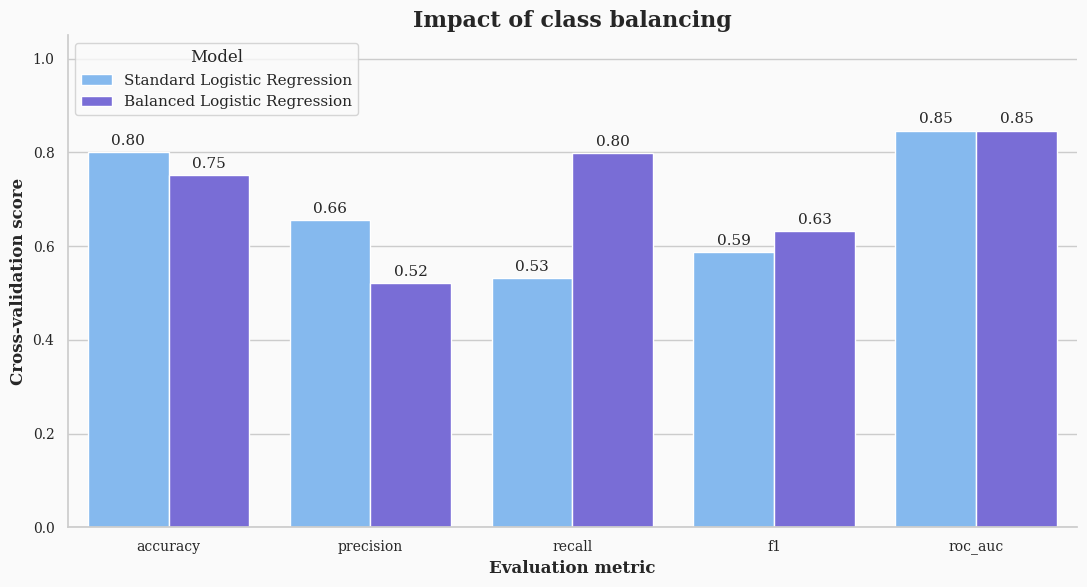

In [19]:
experiment_plot = (
    imbalance_comparison
    .reset_index(names="model")
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score"
    )
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=experiment_plot,
    x="metric",
    y="score",
    hue="model",
    palette=["#74B9FF", "#6C5CE7"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title("Impact of class balancing")
plt.xlabel("Evaluation metric")
plt.ylabel("Cross-validation score")
plt.ylim(0, 1.05)
plt.legend(title="Model")
sns.despine()
plt.tight_layout()
plt.show()

Am vrut sa testez si o varianta diferita a modelului si sa o compar cu rezultatul obtinut initial. Prin urmare, am comparat Logistic Regression standard cu o varianta care foloseste clase echilibrate.

Echilibrarea a crescut recall-ul de la **53,18%** la **79,93%**, dar a redus accuracy si precision, deoarece modelul produce mai multe alarme false.

Am pastrat varianta echilibrata deoarece identifica mai multi clienti care risca sa plece, acesta fiind obiectivul principal al proiectului.

### 6.4 Feature engineering experiment

Am vrut sa verific daca noile caracteristici create de mine imbunatatesc rezultatele modelului.

Am comparat Random Forest folosind datele initiale cu acelasi model care foloseste suplimentar `tenure_group` si `number_of_services`.

In [20]:
X_train_original = X_train.drop(
    columns=[
        "tenure_group",
        "number_of_services"
    ]
)

original_numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

original_categorical_features = [
    column for column in X_train_original.columns
    if column not in original_numeric_features
]

original_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            original_numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            original_categorical_features
        )
    ]
)

forest_original_features = Pipeline(
    steps=[
        (
            "preprocessor",
            original_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

forest_engineered_features = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

original_cv = cross_validate(
    forest_original_features,
    X_train_original,
    y_train,
    cv=5,
    scoring=scoring
)

engineered_cv = cross_validate(
    forest_engineered_features,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

feature_engineering_comparison = pd.DataFrame({
    "Original features": {
        metric: original_cv[f"test_{metric}"].mean()
        for metric in scoring
    },
    "Engineered features": {
        metric: engineered_cv[f"test_{metric}"].mean()
        for metric in scoring
    }
}).T

display(
    feature_engineering_comparison
    .round(4)
    .style
    .highlight_max(
        axis=0,
        color="#C7F9CC"
    )
)

,accuracy,precision,recall,f1,roc_auc
Original features,0.761400,0.535900,0.763900,0.629800,0.847100
Engineered features,0.766800,0.543200,0.769200,0.636600,0.847900


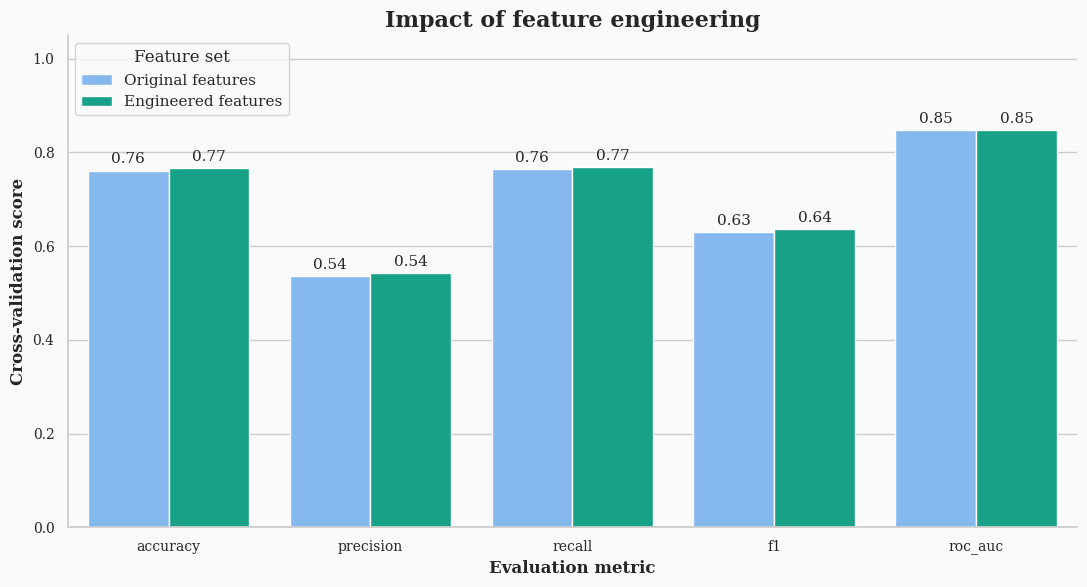

In [21]:
feature_experiment_plot = (
    feature_engineering_comparison
    .reset_index(names="feature_set")
    .melt(
        id_vars="feature_set",
        var_name="metric",
        value_name="score"
    )
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=feature_experiment_plot,
    x="metric",
    y="score",
    hue="feature_set",
    palette=["#74B9FF", "#00B894"]
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title("Impact of feature engineering")
plt.xlabel("Evaluation metric")
plt.ylabel("Cross-validation score")
plt.ylim(0, 1.05)
plt.legend(title="Feature set")
sns.despine()
plt.tight_layout()
plt.show()

Am vrut sa verific daca noile caracteristici create de mine aduc o imbunatatire fata de datele initiale.

Dupa adaugarea `tenure_group` si `number_of_services`, toate metricile au crescut usor. F1-score a crescut de la **62,98%** la **63,66%**, iar recall-ul de la **76,39%** la **76,92%**.

Imbunatatirea este mica, dar apare constant pentru toate metricile. Prin urmare, am pastrat caracteristicile noi in modelul final.

## 7. Model evaluation


### 7.1 Confusion matrices


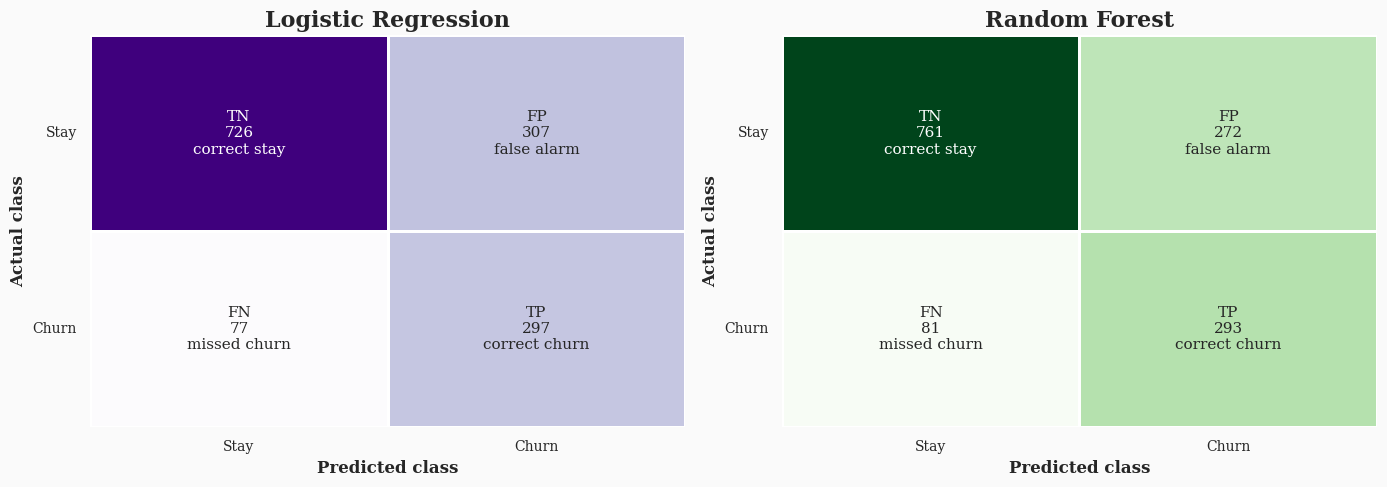

In [22]:
from sklearn.metrics import confusion_matrix

logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

matrices = [
    (
        logistic_cm,
        "Logistic Regression",
        "Purples"
    ),
    (
        random_forest_cm,
        "Random Forest",
        "Greens"
    )
]

for axis, (matrix, title, color) in zip(axes, matrices):
    tn, fp, fn, tp = matrix.ravel()

    annotations = np.array([
        [f"TN\n{tn}\ncorrect stay", f"FP\n{fp}\nfalse alarm"],
        [f"FN\n{fn}\nmissed churn", f"TP\n{tp}\ncorrect churn"]
    ])

    sns.heatmap(
        matrix,
        annot=annotations,
        fmt="",
        cmap=color,
        cbar=False,
        linewidths=2,
        linecolor="white",
        ax=axis
    )

    axis.set_title(title)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
    axis.set_xticklabels(["Stay", "Churn"])
    axis.set_yticklabels(
        ["Stay", "Churn"],
        rotation=0
    )

plt.tight_layout()
plt.show()

Logistic Regression identifica corect **297** dintre clientii care pleaca, dar produce **307 alarme false**.

Random Forest identifica corect **293** dintre clientii care pleaca si reduce alarmele false la **272**.

Logistic Regression identifica cu 4 clienti mai mult, dar Random Forest ofera mai putine alarme false si mai multe predictii corecte in total.

### 7.2 Evaluation metrics



In [23]:
evaluation_results = pd.DataFrame(
    [
        baseline_metrics,
        logistic_metrics,
        random_forest_metrics
    ],
    index=[
        "Dummy Classifier",
        "Logistic Regression",
        "Random Forest"
    ]
)

display(
    evaluation_results
    .round(4)
    .style
    .highlight_max(
        axis=0,
        color="#C7F9CC"
    )
)

,accuracy,precision,recall,f1,roc_auc
Dummy Classifier,0.734200,0.000000,0.000000,0.000000,0.500000
Logistic Regression,0.727100,0.491700,0.794100,0.607400,0.833700
Random Forest,0.749100,0.518600,0.783400,0.624100,0.836900


Am ales recall ca metrica principala deoarece este important sa identificam cat mai multi clienti care urmeaza sa plece.

Logistic Regression obtine cel mai bun recall, de **79,41%**, iar Random Forest obtine **78,34%**.

Random Forest are rezultate mai bune pentru accuracy, precision, F1 si ROC-AUC, ceea ce indica un echilibru general mai bun. Ambele modele sunt mai utile decat baseline-ul, care nu identifica niciun client care pleaca.

### 7.3 ROC curves

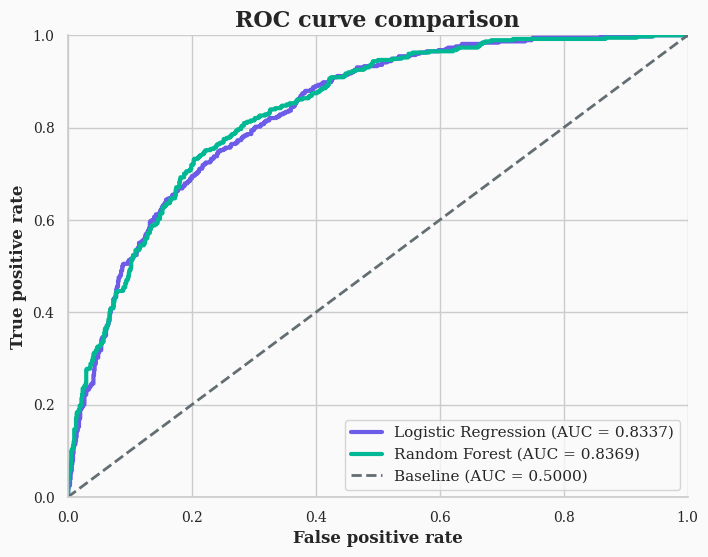

In [24]:
from sklearn.metrics import roc_curve

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

forest_fpr, forest_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    color="#6C5CE7",
    linewidth=3,
    label=f"Logistic Regression (AUC = {logistic_metrics['roc_auc']:.4f})"
)

plt.plot(
    forest_fpr,
    forest_tpr,
    color="#00B894",
    linewidth=3,
    label=f"Random Forest (AUC = {random_forest_metrics['roc_auc']:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#636E72",
    linewidth=2,
    label="Baseline (AUC = 0.5000)"
)

plt.title("ROC curve comparison")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend(loc="lower right")
plt.xlim(0, 1)
plt.ylim(0, 1)
sns.despine()
plt.show()

Ambele modele obtin un ROC-AUC de aproximativ **0,84**, fiind peste baseline-ul de `0,50`.

Random Forest are un rezultat putin mai bun, dar diferenta fata de Logistic Regression este foarte mica. Ambele modele separa destul de bine clientii care pleaca de cei care raman.

### 7.4 Feature importance

,feature,importance
38,Contract_Month-to-month,0.128798
0,tenure,0.108245
40,Contract_Two year,0.073827
2,TotalCharges,0.071220
20,OnlineSecurity_No,0.060070
29,TechSupport_No,0.054495
1,MonthlyCharges,0.053829
18,InternetService_Fiber optic,0.051588
49,tenure_group_new customer,0.044608
45,PaymentMethod_Electronic check,0.037452


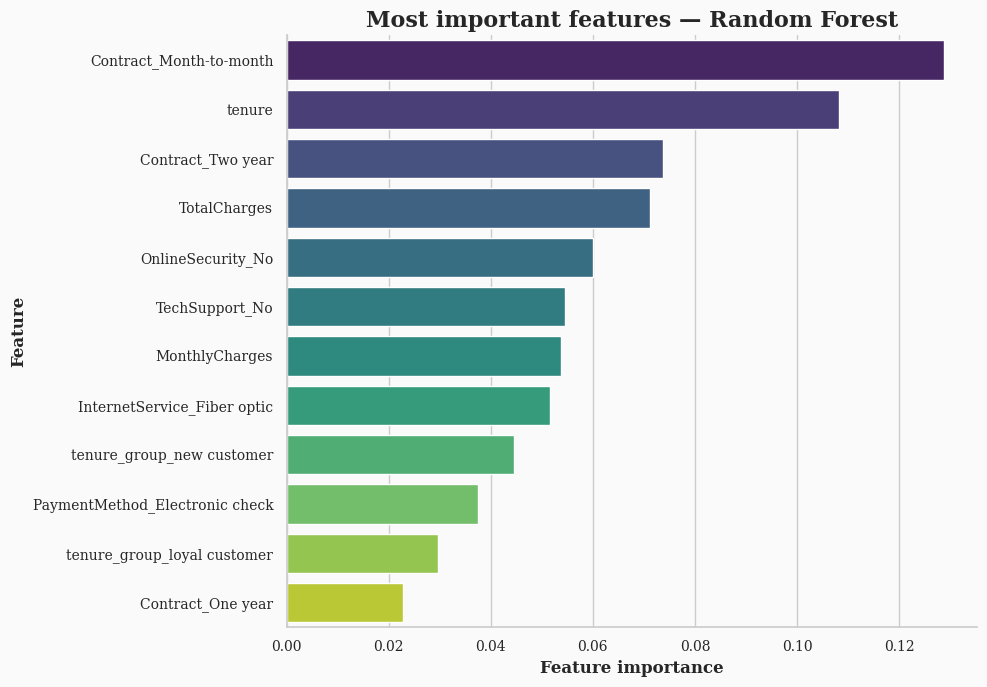

In [25]:
fitted_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

fitted_forest = random_forest_model.named_steps[
    "model"
]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_names = [
    name.replace("numeric__", "")
        .replace("categorical__", "")
    for name in feature_names
]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": fitted_forest.feature_importances_
})

top_features = (
    feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
    .head(12)
)

display(top_features)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Most important features — Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
sns.despine()
plt.tight_layout()
plt.show()

Cele mai importante caracteristici sunt tipul contractului, vechimea clientului si costurile.

Lipsa serviciilor de securitate sau suport tehnic are, de asemenea, o influenta importanta asupra predictiei.

Aceste rezultate arata ce informatii foloseste modelul, dar nu demonstreaza cauzele plecarii clientilor.

### 7.5 Model comparison


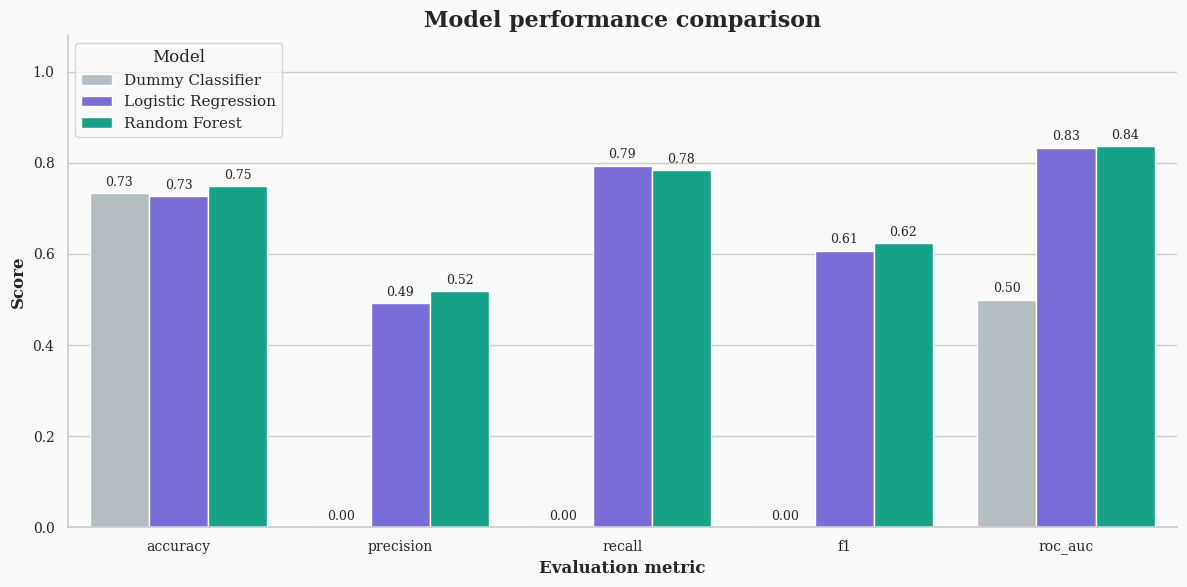

In [26]:
comparison_data = (
    evaluation_results
    .reset_index(names="model")
    .melt(
        id_vars="model",
        var_name="metric",
        value_name="score"
    )
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_data,
    x="metric",
    y="score",
    hue="model",
    palette={
        "Dummy Classifier": "#B2BEC3",
        "Logistic Regression": "#6C5CE7",
        "Random Forest": "#00B894"
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.title("Model performance comparison")
plt.xlabel("Evaluation metric")
plt.ylabel("Score")
plt.ylim(0, 1.08)
plt.legend(title="Model")
sns.despine()
plt.tight_layout()
plt.show()

In [27]:
candidate_results = evaluation_results.drop(
    index="Dummy Classifier"
)

recommended_model = candidate_results[
    "recall"
].idxmax()

best_recall = candidate_results.loc[
    recommended_model,
    "recall"
]

print(
    "recommended model based on recall:",
    recommended_model
)

print(
    f"best recall: {best_recall:.4f}"
)

recommended model based on recall: Logistic Regression
best recall: 0.7941


Logistic Regression obtine cel mai bun recall si identifica aproximativ **79% dintre clientii care pleaca**.

Random Forest produce mai putine alarme false, dar rateaza cu 4 clienti mai mult.

Deoarece obiectivul principal este identificarea unui numar cat mai mare de clienti care risca sa plece, voi recomanda Logistic Regression.

## 8. Conclusions

Initial, am ales Random Forest deoarece obtinea rezultate mai bune pentru majoritatea metricilor si producea mai putine alarme false.

Ulterior, am observat ca aceasta alegere nu era complet aliniata cu obiectivul stabilit la inceputul proiectului. Deoarece am considerat ca este mai costisitor sa nu identificam un client care urmeaza sa plece, recall-ul trebuia sa ramana criteriul principal de selectie.

Prin urmare, am modificat alegerea finala si recomand **Logistic Regression**, deoarece obtine cel mai bun recall si identifica aproximativ **79% dintre clientii care pleaca**.

Modelul obtine un recall de **79,41%**, un F1-score de **60,74%** si un ROC-AUC de **83,37%**. Random Forest produce mai putine alarme false, dar rateaza cu 4 clienti mai mult.

O limitare a analizei este faptul ca datele provin de la o singura companie de telecomunicatii. Din acest motiv, performanta modelului poate fi diferita pentru alti clienti, alte companii sau alte perioade.

## 9. Use of AI Disclaimer

Am folosit Codex AI pentru structurarea proiectului, explicarea etapelor si verificarea codului.

Pe cont propriu, am ajustat explicatiile, graficele si interpretarile, si am adus idei de imbunatatire pentru a reflecta rezultatele obtinute si conceptele studiate la curs.

Am observat ca fontul `DejaVu Sans` recomandat initial nu modifica aspectul graficelor, deoarece era deja fontul standard. Am corectat alegerea si am folosit un font diferit.
